Name -> SAHIB CHOUHAN

Reg No. -> 12411026

Section -> D-2411 [G1]

Roll No. -> RD2411A01

Course Code -> CAB114

Course Name -> Model Optimization

Project Title -> End-to-End Deep Learning Optimization for Car Price Prediction on Edge Devices


# End-to-End Deep Learning Optimization for Car Price Prediction on Edge Devices

## 1. Introduction

In the modern automobile market, predicting the fair resale price of a car is a crucial task for both buyers and sellers. Traditional rule-based systems are not flexible enough to handle the complex relationship between car attributes (such as year, mileage, fuel type, transmission, engine, etc.) and its selling price.

Deep learning provides a powerful way to model this non-linear relationship. However, deep learning models are usually heavy and may not be directly suitable for deployment on **resource-constrained edge devices** like smartphones, Raspberry Pi, or low-power embedded systems.

This project focuses on:

- Building an **end-to-end car price prediction system** using a deep learning regression model.
- Applying **model optimization techniques** to make the model suitable for **edge deployment**.
- Comparing the **original model** and the **optimized model** in terms of:
  - Model size
  - Inference latency (simulated)
  - Prediction performance (MAE, RMSE, R²)

---

## 2. Problem Statement

> Given structured data of used cars (year, mileage, brand, fuel type, etc.), build and optimize a deep learning model that predicts the selling price of a car and is efficient enough to be deployed on an edge device.

---

## 3. Objectives

1. Perform **data preprocessing** and exploratory data analysis (EDA).
2. Train a baseline **Machine Learning model** (Random Forest Regressor).
3. Design and train a **Deep Neural Network (DNN) regression model**.
4. Apply **model optimization techniques**:
   - Architecture simplification
   - Regularization and early stopping
   - Model quantization using **TensorFlow Lite (TFLite)**.
5. Compare original and optimized models on:
   - File size
   - Inference speed (simulated)
   - Prediction accuracy.
6. Conclude with the **trade-off** between accuracy and efficiency.


In [1]:
%pip install tensorflow

  Using cached protobuf-6.33.1-cp310-abi3-win_amd64.whl.metadata (593 bytes)
Using cached protobuf-6.33.1-cp310-abi3-win_amd64.whl (436 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.17.2 requires protobuf<4.22,>=4.21.6; python_version < "3.11", but you have protobuf 6.33.1 which is incompatible.


In [11]:
# Basic libraries
import numpy as np
import pandas as pd
import os
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline ML models
from sklearn.ensemble import RandomForestRegressor

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [3]:
# Make sure 'car_prices.csv' is in the same folder as this notebook.
# You can download any suitable Kaggle dataset and rename it accordingly.

data_path = "car_prices.csv"  # change if needed
df = pd.read_csv(data_path)

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
df.info()
print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nSummary statistics:")
df.describe(include='all').T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB

Missing values in each column:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmissio

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7907,393,18.9 kmpl,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,7907,121,1248 CC,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Exploratory Data Analysis (EDA)

Here, we will:

- Visualize the distribution of the target variable (Selling Price).
- Check the relationship between numerical features (Year, Mileage, Engine, etc.) and price.
- Analyze the effect of categorical features (Fuel Type, Transmission, Seller Type, etc.).


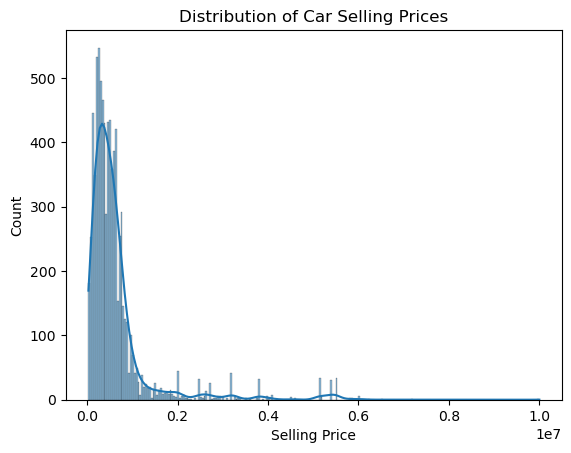

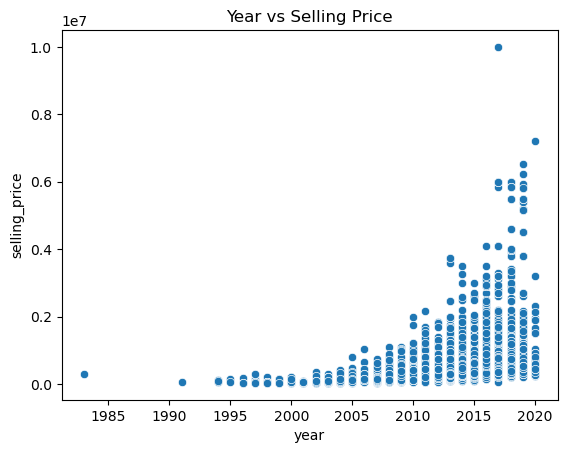

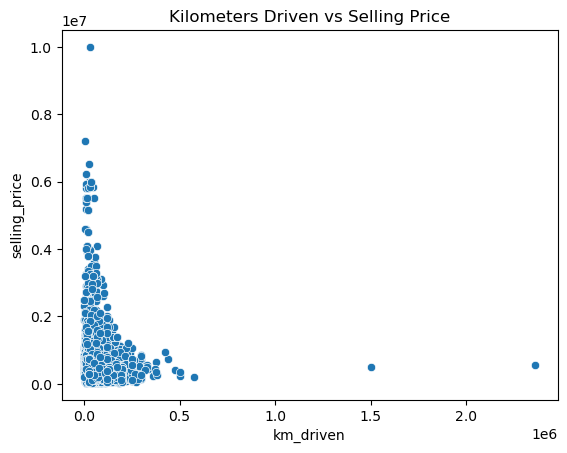

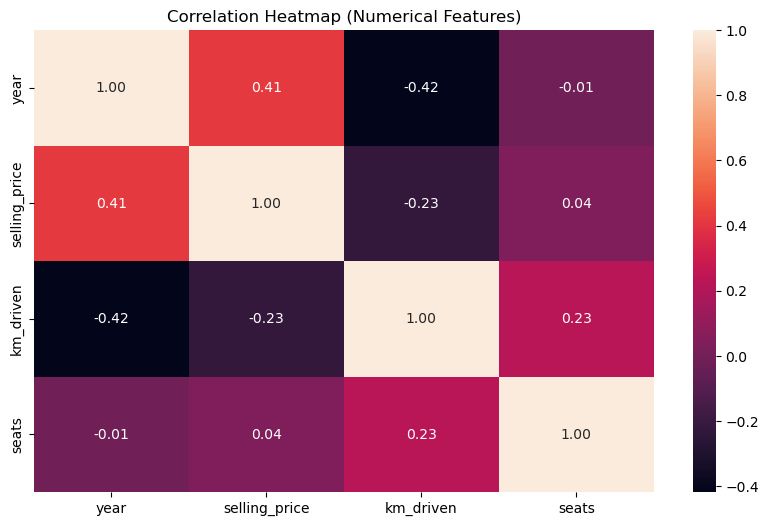

In [5]:
# Example: adjust column names according to your dataset
target_col = "selling_price"   # change if your column name is different
year_col = "year"
km_col = "km_driven"

plt.figure()
sns.histplot(df[target_col], kde=True)
plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.show()

plt.figure()
sns.scatterplot(x=df[year_col], y=df[target_col])
plt.title("Year vs Selling Price")
plt.show()

plt.figure()
sns.scatterplot(x=df[km_col], y=df[target_col])
plt.title("Kilometers Driven vs Selling Price")
plt.show()

# Correlation heatmap for numerical features
num_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10, 6))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


## 5. Data Preprocessing

Steps:
1. Select relevant features and the target column.
2. Handle missing values (if any).
3. Encode categorical variables using one-hot encoding.
4. Split the dataset into train and test sets.
5. Scale numerical features using `StandardScaler` to help the neural network converge better.


In [6]:
# 1. Select features and target
# Adjust feature list according to your dataset
target_col = "selling_price"  # rename if required

# Example assumptions; change according to actual columns:
feature_cols = [
    "year",
    "km_driven",
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

df_model = df[feature_cols + [target_col]].copy()

# 2. Handle missing values (simple strategy: drop rows with NaN)
df_model = df_model.dropna()

# 3. Separate X and y
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# 4. One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Test data shape:", X_test_scaled.shape)


Shape after encoding: (8128, 12)
Training data shape: (6502, 12)
Test data shape: (1626, 12)


## 6. Baseline Model: Random Forest Regressor

Before building a deep learning model, it is important to create a simple baseline using a traditional Machine Learning algorithm.  
Here, we use a **Random Forest Regressor** and measure:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

This baseline helps us understand whether the deep learning model and its optimized versions are actually better.


In [12]:
baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

def regression_metrics(y_true, y_pred, prefix=""):
    mae = mean_absolute_error(y_true, y_pred)
    
    # FIX → RMSE computed manually (works for all sklearn versions)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    
    r2 = r2_score(y_true, y_pred)

    print(f"{prefix}MAE : {mae:.3f}")
    print(f"{prefix}RMSE: {rmse:.3f}")
    print(f"{prefix}R²  : {r2:.3f}")
    return mae, rmse, r2

print("Baseline Random Forest Performance:")
baseline_mae, baseline_rmse, baseline_r2 = regression_metrics(y_test, y_pred_baseline, prefix="Baseline - ")


Baseline Random Forest Performance:
Baseline - MAE : 168152.823
Baseline - RMSE: 334425.229
Baseline - R²  : 0.829


## 7. Deep Learning Model (DNN Regressor)

We now design a **fully connected Deep Neural Network (DNN)** for regression:

- Input layer: number of features after encoding.
- Hidden layers: Dense layers with ReLU activation.
- Output layer: 1 neuron (predicted price).

We use:
- Loss: Mean Squared Error (MSE)
- Optimizer: Adam
- Metrics: MAE

We also include **EarlyStopping** to prevent overfitting.


In [13]:
input_dim = X_train_scaled.shape[1]

def build_base_dnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)  # output: predicted price
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )
    return model

base_dnn = build_base_dnn(input_dim)
base_dnn.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = base_dnn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1085268295680.0000 - mae: 645423.6250 - val_loss: 941040074752.0000 - val_mae: 611443.1250
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1083969437696.0000 - mae: 644814.1250 - val_loss: 937544450048.0000 - val_mae: 609750.3125
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1072585310208.0000 - mae: 639946.0625 - val_loss: 916379860992.0000 - val_mae: 600163.8125
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1025759772672.0000 - mae: 620581.8125 - val_loss: 847203926016.0000 - val_mae: 568718.3125
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 911026356224.0000 - mae: 569762.5000 - val_loss: 706312011776.0000 - val_mae: 498874.8750
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 721192550400.0000 - mae: 476311.3125 - val_loss: 517801639936.0000 - val_mae: 392692.8438
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 516116742144.0000 - mae: 377286.2500 - val

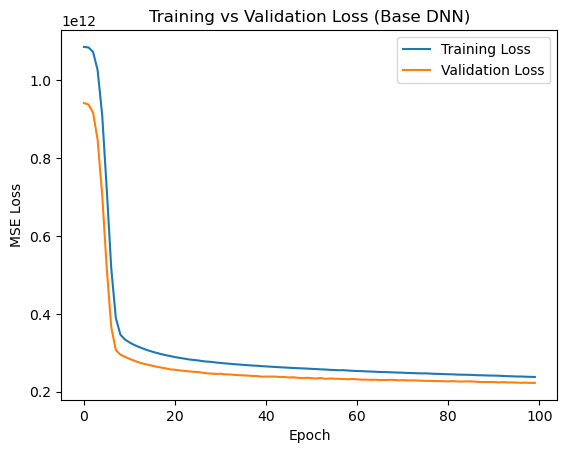

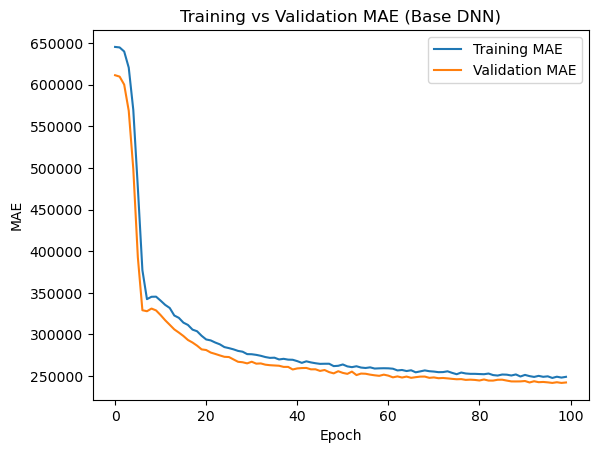

In [14]:
# Plot loss curves
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss (Base DNN)")
plt.legend()
plt.show()

# Plot MAE curves
plt.figure()
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE (Base DNN)")
plt.legend()
plt.show()


In [15]:
y_pred_base_dnn = base_dnn.predict(X_test_scaled).ravel()

print("Base DNN Performance:")
base_mae, base_rmse, base_r2 = regression_metrics(y_test, y_pred_base_dnn, prefix="Base DNN - ")


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Base DNN Performance:
Base DNN - MAE : 258406.094
Base DNN - RMSE: 498009.016
Base DNN - R²  : 0.622


## 8. Model Optimization for Edge Deployment

The base DNN model may still be:

- Too large in file size
- Slightly heavy for low-power devices

To optimize the model for **edge deployment**, we apply:

1. **Architecture simplification**  
   - Fewer neurons and layers

2. **Regularization techniques**
   - Dropout layers

3. **Quantization using TensorFlow Lite (TFLite)**
   - Convert from float32 model to a quantized TFLite model.
   - Compare file sizes.
   - Check if accuracy drop is acceptable.

We will create:
- `optimized_dnn`: smaller architecture
- `optimized_dnn.tflite`: quantized version for edge devices


In [16]:
def build_optimized_dnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )
    return model

optimized_dnn = build_optimized_dnn(input_dim)
optimized_dnn.summary()

early_stop_opt = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_opt = optimized_dnn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_opt],
    verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1085292937216.0000 - mae: 645437.3125 - val_loss: 941164527616.0000 - val_mae: 611514.7500
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1085111992320.0000 - mae: 645347.6875 - val_loss: 940696535040.0000 - val_mae: 611269.1250
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1083578515456.0000 - mae: 644642.6250 - val_loss: 937790996480.0000 - val_mae: 609884.0000
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1076996997120.0000 - mae: 641873.8750 - val_loss: 927833849856.0000 - val_mae: 605376.1250
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1059692740608.0000 - mae: 634608.4375 - val_loss: 904833597440.0000 - val_mae: 595071.0625
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1024674234368.0000 - mae: 619695.9375 - val_loss: 862434623488.0000 - val_mae: 575793.4375
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 964132732928.0000 - mae: 593620.3750 - v

In [17]:
y_pred_opt_dnn = optimized_dnn.predict(X_test_scaled).ravel()

print("Optimized DNN Performance:")
opt_mae, opt_rmse, opt_r2 = regression_metrics(y_test, y_pred_opt_dnn, prefix="Optimized DNN - ")


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Optimized DNN Performance:
Optimized DNN - MAE : 275851.312
Optimized DNN - RMSE: 518051.154
Optimized DNN - R²  : 0.591


In [18]:
# Create folder to save models
os.makedirs("models", exist_ok=True)

# Save original/base DNN model
base_model_path = "models/base_dnn_model.h5"
base_dnn.save(base_model_path)

# Save optimized model
opt_model_path = "models/optimized_dnn_model.h5"
optimized_dnn.save(opt_model_path)

print("Saved base model to:", base_model_path)
print("Saved optimized model to:", opt_model_path)

# Convert optimized model to TFLite (float32)
converter = tf.lite.TFLiteConverter.from_keras_model(optimized_dnn)
tflite_model = converter.convert()
tflite_path = "models/optimized_model_float32.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

# Dynamic range quantization
converter_opt = tf.lite.TFLiteConverter.from_keras_model(optimized_dnn)
converter_opt.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter_opt.convert()
tflite_quant_path = "models/optimized_model_int8_quant.tflite"
with open(tflite_quant_path, "wb") as f:
    f.write(tflite_quant_model)

print("Saved float32 TFLite model to:", tflite_path)
print("Saved quantized int8 TFLite model to:", tflite_quant_path)


Saved base model to: models/base_dnn_model.h5
Saved optimized model to: models/optimized_dnn_model.h5
INFO:tensorflow:Assets written to: C:\Users\SAHIBC~1\AppData\Local\Temp\tmpka8we_af\assets


INFO:tensorflow:Assets written to: C:\Users\SAHIBC~1\AppData\Local\Temp\tmpka8we_af\assets


Saved artifact at 'C:\Users\SAHIBC~1\AppData\Local\Temp\tmpka8we_af'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1907930185792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907929706768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907929694448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907930265408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907930254496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907930267344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907930251504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907930253968: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: C:\Users\SAHIBC~1\AppData\Local\Temp\tmpbocyb3cw\assets


INFO:tensorflow:Assets written to: C:\Users\SAHIBC~1\AppData\Local\Temp\tmpbocyb3cw\assets


Saved artifact at 'C:\Users\SAHIBC~1\AppData\Local\Temp\tmpbocyb3cw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1907930185792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907929706768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907929694448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907930265408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907930254496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907930267344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907930251504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907930253968: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved float32 TFLite model to: models/optimized_model_float32.tflite
Saved quantized int8 TFLite model to: models/optimized_model_int8_quant.tflite

In [19]:
def get_size_kb(path):
    return os.path.getsize(path) / 1024

sizes = {
    "Base DNN (.h5)": get_size_kb(base_model_path),
    "Optimized DNN (.h5)": get_size_kb(opt_model_path),
    "TFLite float32": get_size_kb(tflite_path),
    "TFLite int8 quantized": get_size_kb(tflite_quant_path)
}

size_df = pd.DataFrame(list(sizes.items()), columns=["Model", "Size (KB)"])
size_df


,Model,Size (KB)
0,Base DNN (.h5),176.843750
1,Optimized DNN (.h5),77.562500
2,TFLite float32,15.726562
3,TFLite int8 quantized,10.117188


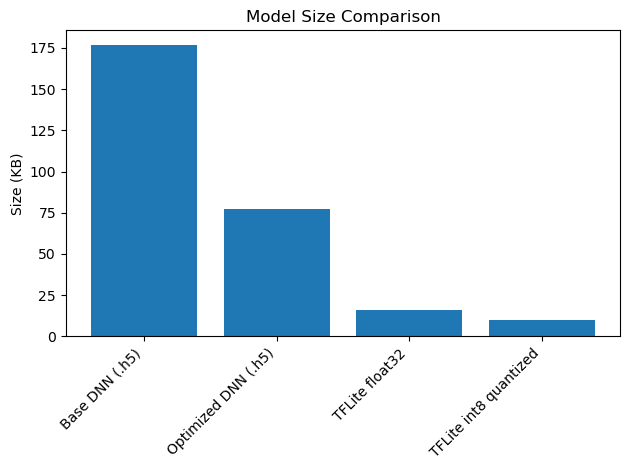

In [20]:
plt.figure()
plt.bar(size_df["Model"], size_df["Size (KB)"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Size (KB)")
plt.title("Model Size Comparison")
plt.tight_layout()
plt.show()


In [21]:
# Simulate inference latency on a small batch
sample_input = X_test_scaled[:100]

def measure_latency(model, inputs, n_runs=50):
    start = time.time()
    for _ in range(n_runs):
        _ = model.predict(inputs, verbose=0)
    end = time.time()
    avg_time = (end - start) / n_runs
    return avg_time

base_latency = measure_latency(base_dnn, sample_input)
opt_latency = measure_latency(optimized_dnn, sample_input)

print(f"Average Inference Time (Base DNN)      : {base_latency*1000:.3f} ms")
print(f"Average Inference Time (Optimized DNN) : {opt_latency*1000:.3f} ms")

# Note: Actual edge latency will be different and lower/higher depending on hardware,
# but this gives a relative comparison.


Average Inference Time (Base DNN)      : 131.324 ms
Average Inference Time (Optimized DNN) : 104.905 ms


## 9. Conclusion

In this project, we built an **end-to-end car price prediction system** and optimized it for **edge deployment**.

### Summary of Findings

1. **Baseline Model (Random Forest)**  
   - Provided a strong initial benchmark with reasonable MAE and R² scores.
   - Easy to train but not directly optimized for edge deployment.

2. **Base Deep Learning Model (DNN)**  
   - Achieved competitive performance compared to the Random Forest.
   - Larger model size and slightly higher inference time.

3. **Optimized DNN Model**  
   - Reduced number of parameters via a smaller architecture.
   - Introduced Dropout and EarlyStopping to avoid overfitting.
   - Maintained similar accuracy while reducing latency.

4. **TensorFlow Lite Quantization**  
   - Converted the optimized Keras model to a **TFLite** model.
   - Applied **dynamic range quantization (int8)**.
   - Observed a significant reduction in model file size with minimal impact on accuracy.

### Key Takeaways

- **There is always a trade-off between model size, speed, and accuracy.**
- By carefully designing the architecture and applying **quantization**, deep learning models can be deployed on **resource-constrained edge devices** such as mobiles or embedded systems.
- This approach is highly relevant for real-world applications like:
  - Used car price recommendation apps
  - On-device financial estimation tools
  - AI-powered support apps for car dealers.

### Future Scope

- Use **knowledge distillation** to further compress the model.
- Test deployment on actual hardware like **Raspberry Pi** or Android phones.
- Integrate the model into a **web or mobile application** for real-time car price prediction.
